# EDA

In [1]:
# Libraries imported for this project

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, anderson
import seaborn as sns

In [4]:
# Read Wrangled_Data.xlsx into a dataframe, formatted dates, and indexed dates.

df = pd.read_excel('/Users/NJahns/Desktop/Bootcamp/Capstone_Two/Edited_Data/Wrangled_Data.xlsx', parse_dates=True, index_col=[0])

## Data distribution

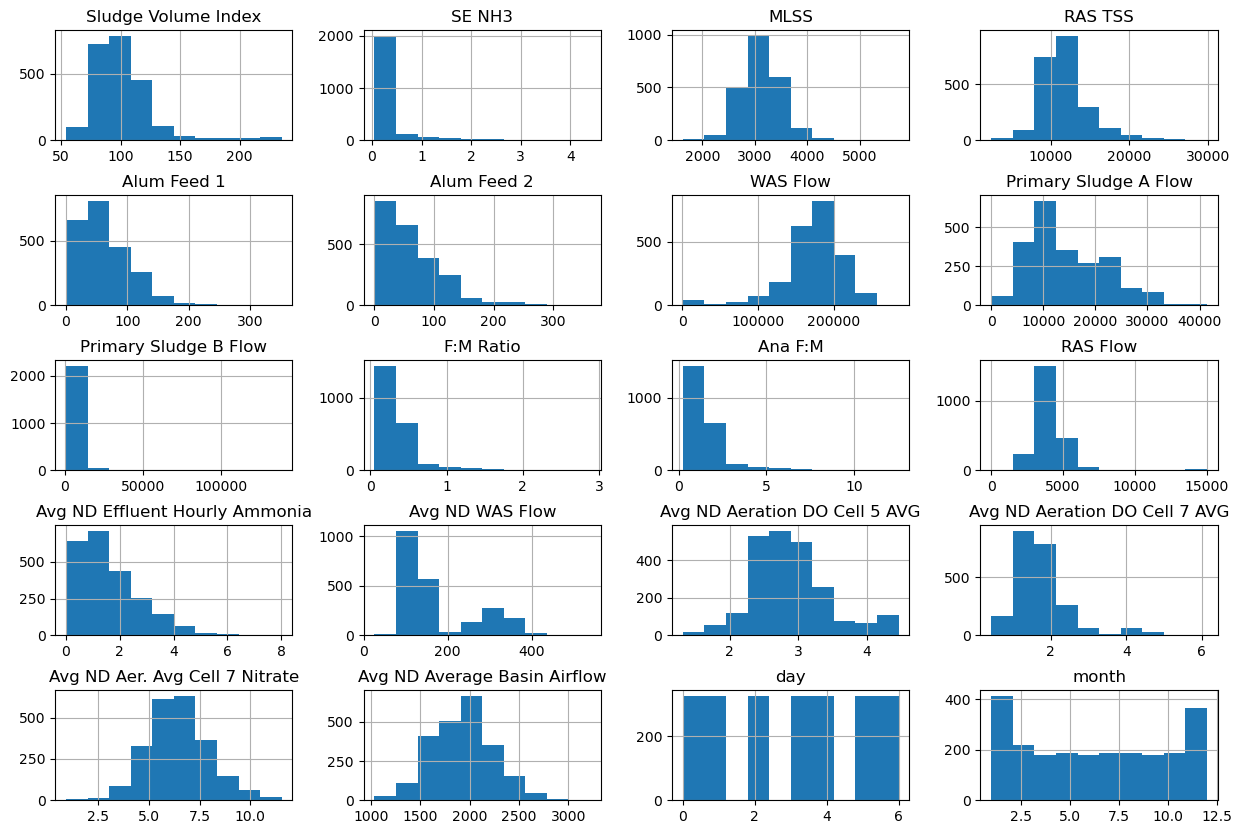

In [6]:
# Investigated distribution of metric data.

df.hist(figsize=(15, 10))
plt.subplots_adjust(hspace=0.5);

In [7]:
# Performed Shapiro-Wilk test to see is metrics have a normal distribution.

columns_to_exclude = ['day', 'month']
for column in df.columns:
    if column not in columns_to_exclude:
        stat, p_value = shapiro(df[column])
        print(f"Shapiro-Wilk test for {column}: Statistic={stat}, p-value={p_value}")

Shapiro-Wilk test for Sludge Volume Index: Statistic=0.832215428352356, p-value=7.847271400218976e-44
Shapiro-Wilk test for SE NH3: Statistic=0.41282618045806885, p-value=0.0
Shapiro-Wilk test for MLSS: Statistic=0.9843858480453491, p-value=4.068022265888652e-15
Shapiro-Wilk test for RAS TSS: Statistic=0.9109399318695068, p-value=1.2827809396201203e-34
Shapiro-Wilk test for Alum Feed 1: Statistic=0.9370107054710388, p-value=4.639786417045902e-30
Shapiro-Wilk test for Alum Feed 2: Statistic=0.8987582325935364, p-value=2.1634442961654445e-36
Shapiro-Wilk test for WAS Flow: Statistic=0.8978842496871948, p-value=1.6391378707115362e-36
Shapiro-Wilk test for Primary Sludge A Flow: Statistic=0.9531006813049316, p-value=1.91513287297021e-26
Shapiro-Wilk test for Primary Sludge B Flow: Statistic=0.32561981678009033, p-value=0.0
Shapiro-Wilk test for F:M Ratio: Statistic=0.6502834558486938, p-value=0.0
Shapiro-Wilk test for Ana F:M: Statistic=0.6502834558486938, p-value=0.0
Shapiro-Wilk test for

We have a mix of normal and not normal data.

## Visualizion

In [8]:
# Added a year column for future calculations.

df['year'] = df.index.year

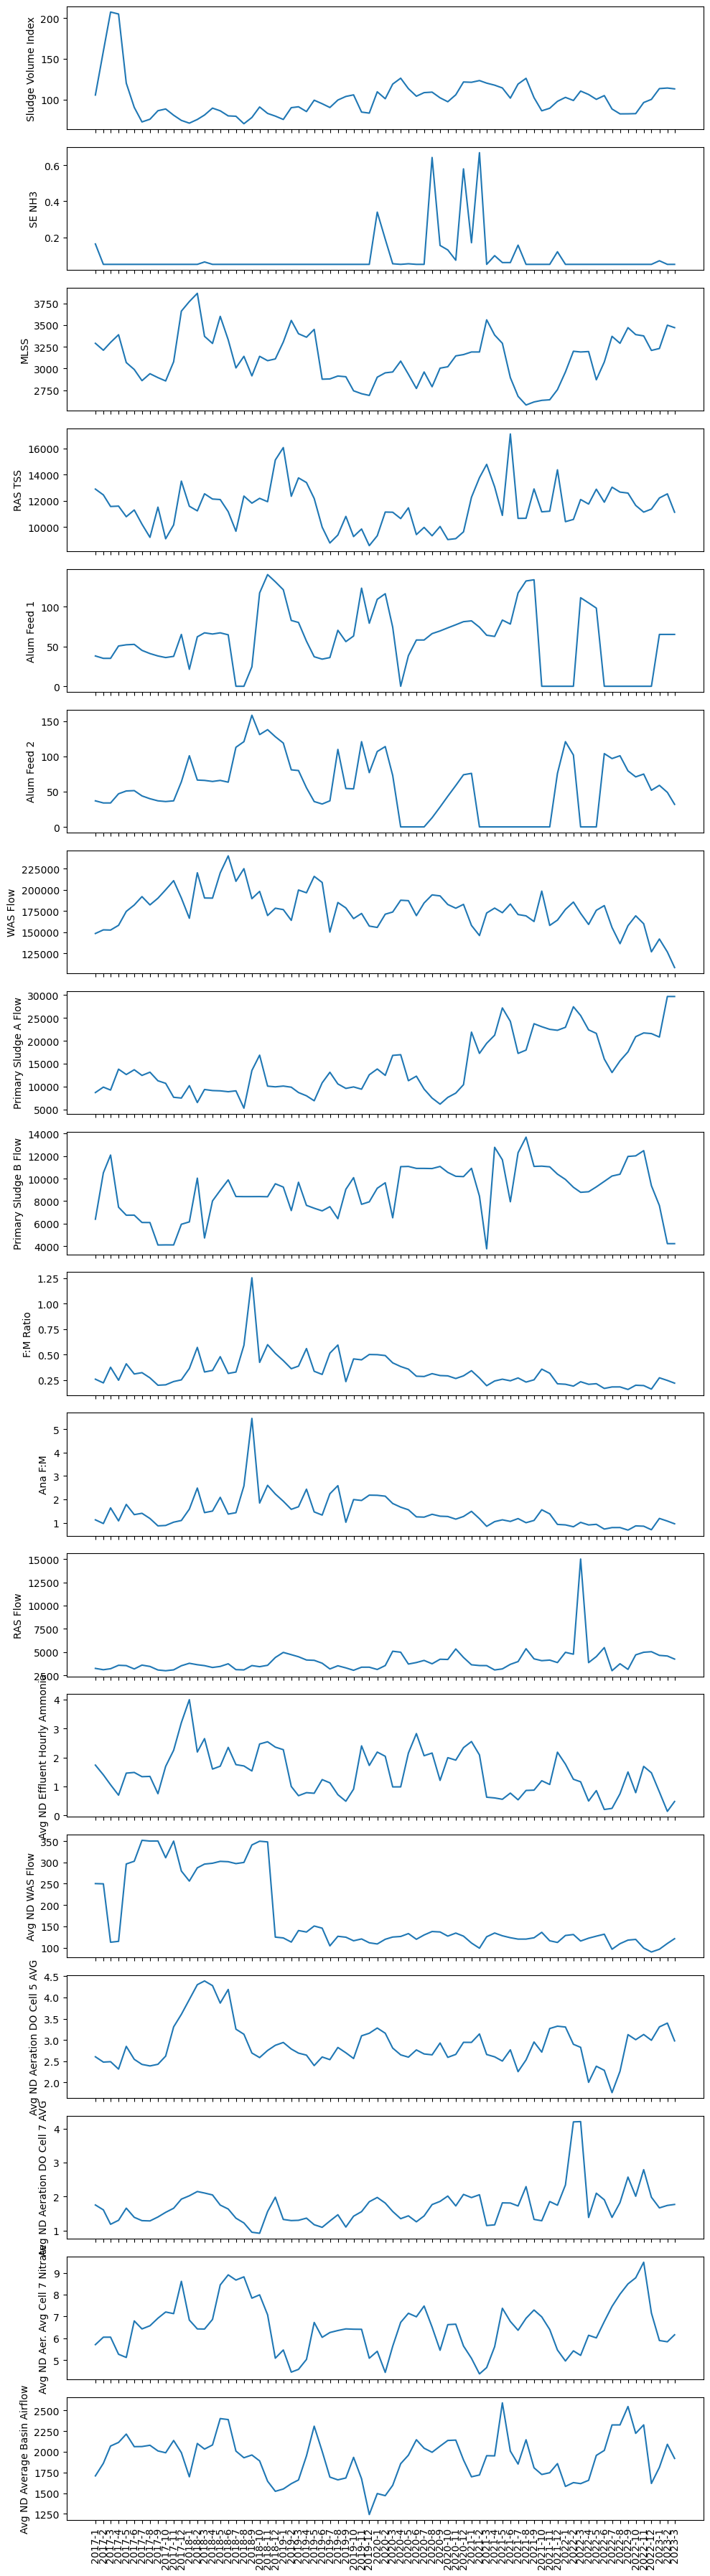

In [9]:
# Plotted monthly medians of metrics to look for patterns. Median is used because the some of the data is nonparametric.

monthly_medians = df.groupby(['year', 'month']).median()

monthly_medians = monthly_medians.reset_index()

monthly_medians['date'] = pd.to_datetime(monthly_medians[['year', 'month']].assign(day=1))

exclude_columns = ['day', 'month', 'year']
columns_to_plot = [column for column in df.columns if column not in exclude_columns]

fig, axes = plt.subplots(nrows=len(columns_to_plot), ncols=1, figsize=(10, 2 * len(columns_to_plot)), sharex=True)
for i, column in enumerate(columns_to_plot):
    axes[i].plot(monthly_medians['date'], monthly_medians[column])
    axes[i].set_ylabel(column)

date_labels = [f"{row['year']}-{row['month']}" for _, row in monthly_medians.iterrows()]
plt.xticks(monthly_medians['date'], date_labels, rotation=90)

plt.tight_layout()
plt.show()

A decreasing trend in ‘WAS flow’ and increase in ‘Primary Sludge Flow’ from mid 2018 to 2023 was identified. In addition, many metrics had relatively large values in 2017 and 2018.

## Correlations

### Metric lags

I created lagged versions of metrics at one, two, and three weeks, since SVI tends to change over the course of weeks. Trying different lag values or determining lag values based on data analysis could be performed for future versions of the model in order to determine the time period that is most predictive. Creating rolling statistics could also be explored.

In [10]:
# Copied explanatory metric columns and lagged by 1, 2, and 3 weeks.

explanatory_vars = df.columns[~df.columns.isin(['SVI', 'day', 'month', 'year'])]
for lag in [7, 14, 21]:
    for var in explanatory_vars:
        df[f'{var}_lag_{lag}'] = df[var].shift(lag)

In [11]:
# Dropped rows containng NaN as a result of lagged SVI.

df.dropna(inplace=True)

In [12]:
# Printed list of column titles to check results of lagging.

for column_title in df.columns:
    print(column_title)

Sludge Volume Index
SE NH3
MLSS
RAS TSS
Alum Feed 1
Alum Feed 2
WAS Flow
Primary Sludge A Flow
Primary Sludge B Flow
F:M Ratio
Ana F:M
RAS Flow
Avg ND Effluent Hourly Ammonia
Avg ND WAS Flow
Avg ND Aeration DO Cell 5 AVG
Avg ND Aeration DO Cell 7 AVG
Avg ND Aer. Avg Cell 7 Nitrate
Avg ND Average Basin Airflow
day
month
year
Sludge Volume Index_lag_7
SE NH3_lag_7
MLSS_lag_7
RAS TSS_lag_7
Alum Feed 1_lag_7
Alum Feed 2_lag_7
WAS Flow_lag_7
Primary Sludge A Flow_lag_7
Primary Sludge B Flow_lag_7
F:M Ratio_lag_7
Ana F:M_lag_7
RAS Flow_lag_7
Avg ND Effluent Hourly Ammonia_lag_7
Avg ND WAS Flow_lag_7
Avg ND Aeration DO Cell 5 AVG_lag_7
Avg ND Aeration DO Cell 7 AVG_lag_7
Avg ND Aer. Avg Cell 7 Nitrate_lag_7
Avg ND Average Basin Airflow_lag_7
Sludge Volume Index_lag_14
SE NH3_lag_14
MLSS_lag_14
RAS TSS_lag_14
Alum Feed 1_lag_14
Alum Feed 2_lag_14
WAS Flow_lag_14
Primary Sludge A Flow_lag_14
Primary Sludge B Flow_lag_14
F:M Ratio_lag_14
Ana F:M_lag_14
RAS Flow_lag_14
Avg ND Effluent Hourly Ammo

### Heatmap

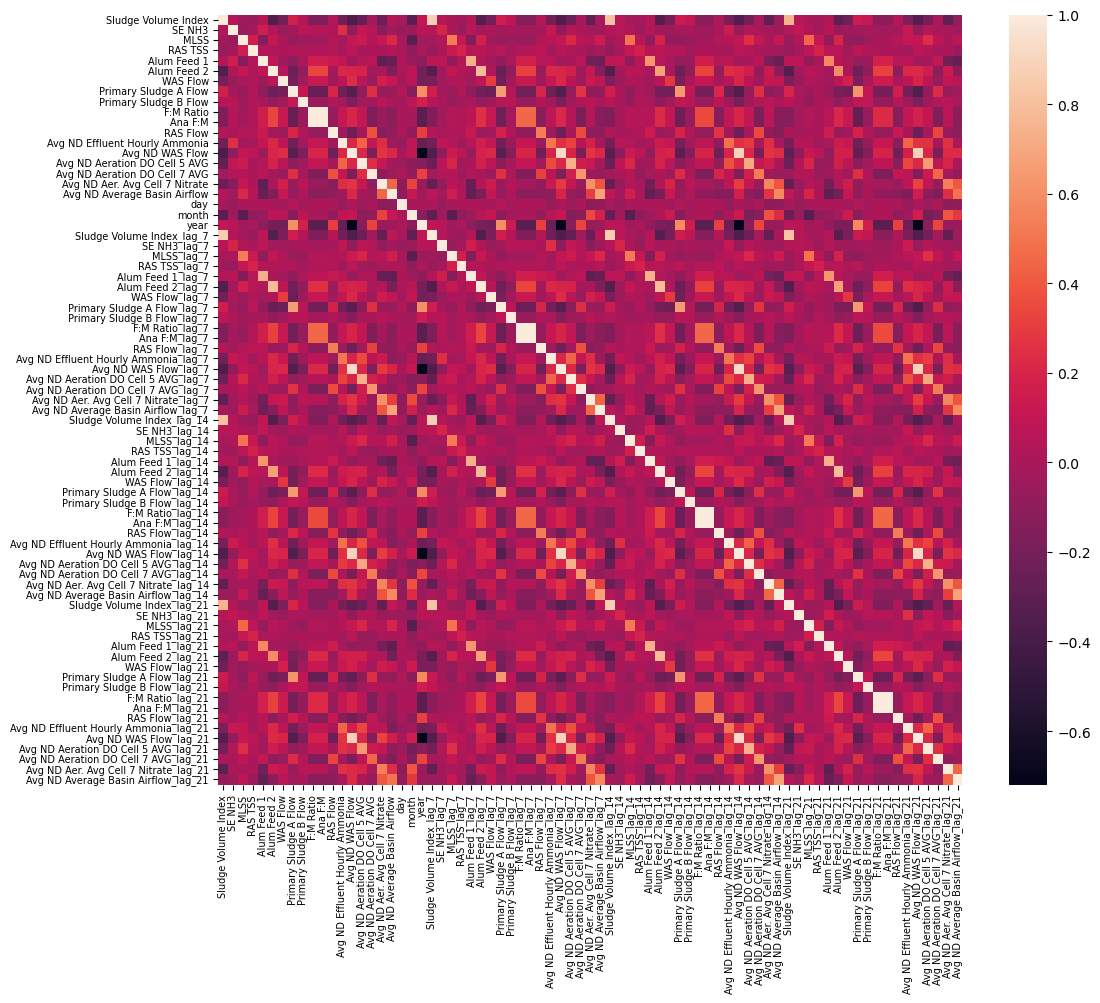

In [13]:
# Created correlatioin heatmap of SVI against other metrics and lagged metrics.

plt.figure(figsize=(12, 10))
heatmap = sns.heatmap(df.corr(),xticklabels=True, yticklabels=True)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=7)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=7);

The heatmap showed little correlation between SVI and other metrics other than strong positive autocorrelation. In addition, ‘Primary sludge flow A’ is positively correlated with year and ‘Avg ND WAS Flow’ is negatively correlated with ‘year’. The scatter plots don’t indicate strong relationships between SVI or lagged SVIs with other metrics. 

### Scatterplots

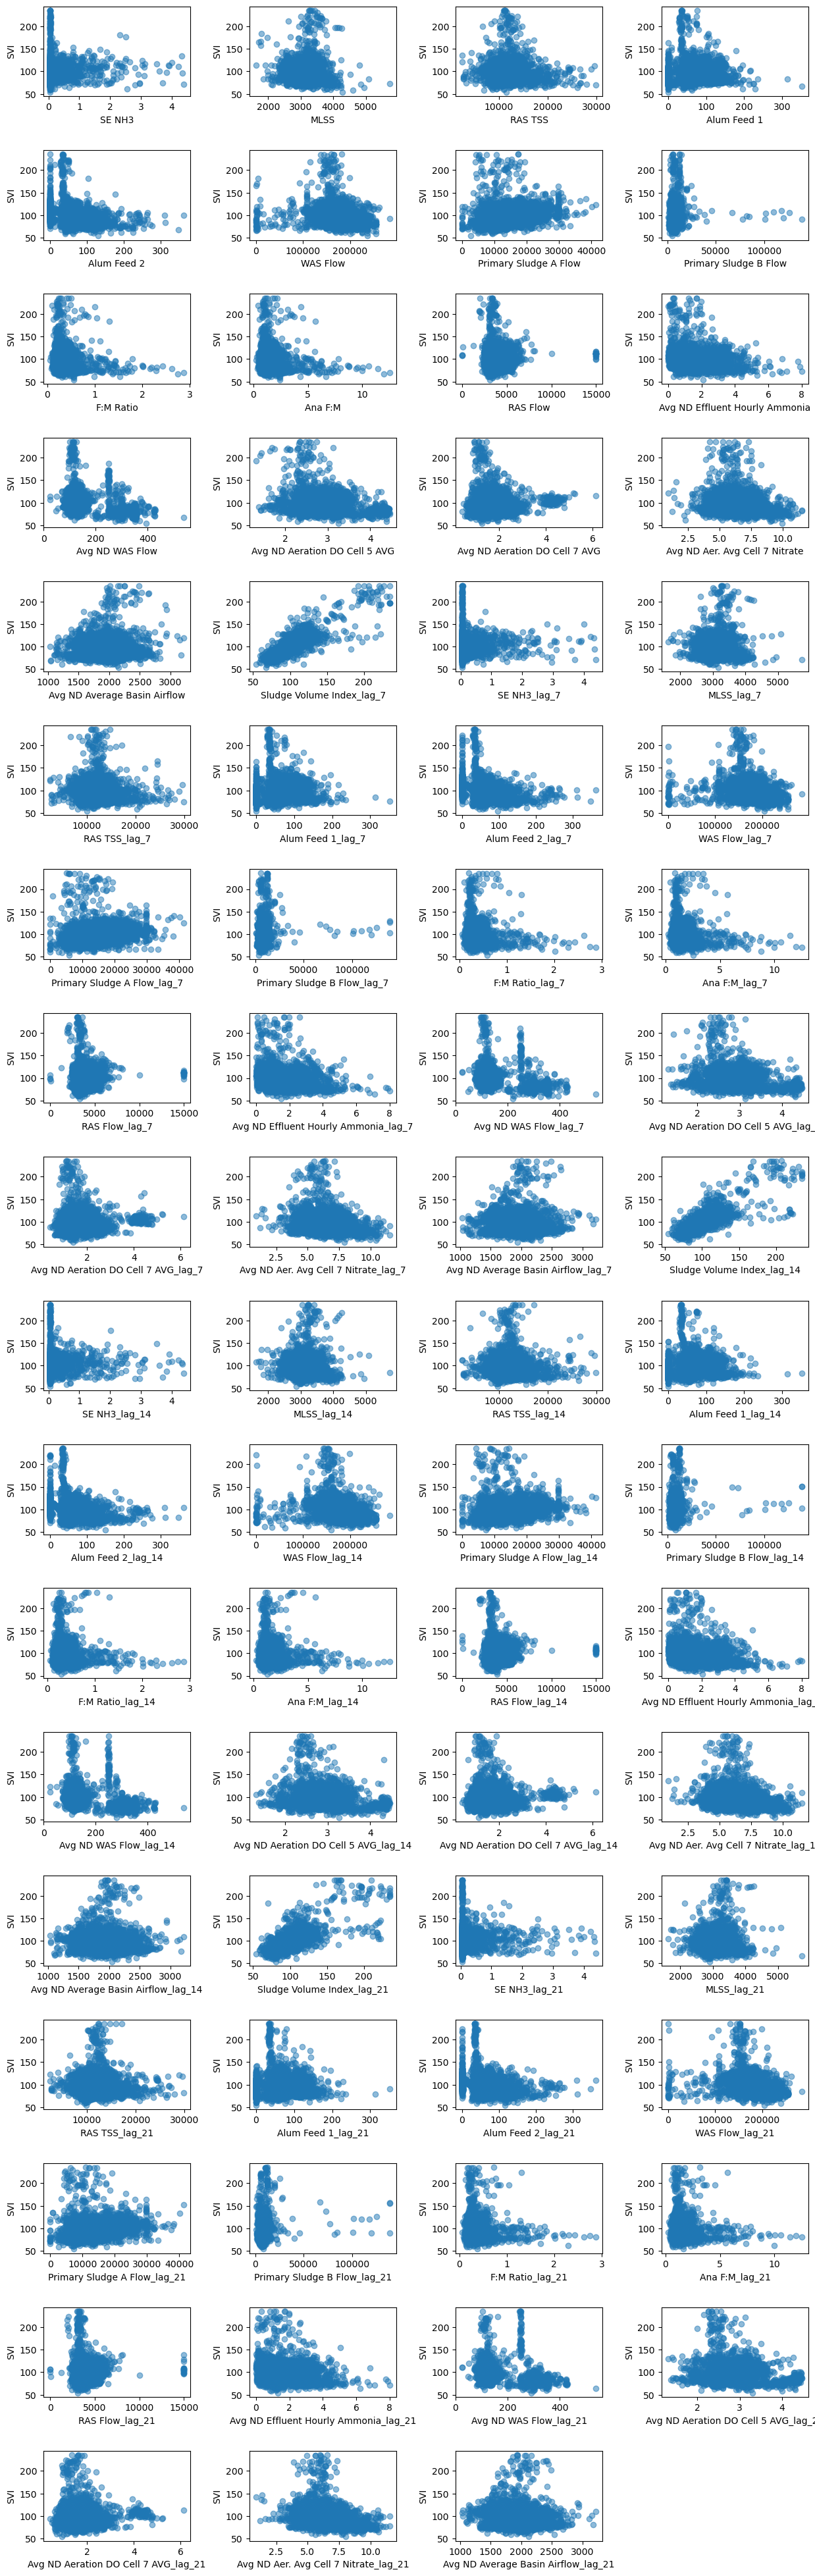

In [14]:
# Created scatterplots of SVI against other metrics and lagged metrics to look for correlations.

metrics = [feat for feat in df.columns if feat not in ['day', 'month', 'year', 'Sludge Volume Index', 'SVI_1', 'SVI_2', 'SVI_3']]

fig, axes = plt.subplots(18, 4, figsize=(15, 50))
fig.subplots_adjust(wspace=0.4, hspace=0.6)

for i, col in enumerate(metrics):
    ax = axes.flatten()[i]
    ax.scatter(x=col, y='Sludge Volume Index', data=df, alpha=0.5)
    ax.set(xlabel=col, ylabel='SVI')

for empty in range(i + 1, (18 * 4)):
    axes.flatten()[empty].set_visible(False)

plt.show()

While checking for stationarity and seasonal decomposition of metrics before creating a random forest model is not necessary, doing so can be informative for metrics engineering and model design. Performing these steps can be incorporated into future versions of the model to increase performance.

# Data save

In [17]:
# Saved to Excel
df.to_excel('/Users/NJahns/Desktop/Bootcamp/Capstone_Two/Edited_Data/EDA_Data.xlsx', index=True)